# <center>Portfolio Optimization Analysis of AI/Technology stocks</center>

In the current financial market, portfolio optimization is all about striking the right balance between risk and return. Rather than relying on intuition and equal-weight allocation of assets, we use a quantitative optimization approach to construct portfolios from a concentrated universe of large-cap technology stocks. We will be running the Monte Carlo Simulation for an optimal portfolio with resulting returns. The stocks that will be analyzed are:
1. Apple
2. Microsoft
3. Google
4. Amazon
5. Nvidia
6. Meta
7. Tesla
8. Oracle
9. AMD
10. IBM

The objective of this analysis is to illustrate the application of classical portfolio optimization techniques, such as mean-variance optimization, and explain the underlying assumptions and limitations of the analysis, while keeping the analysis as simple as possible and avoiding the complexities of the model.

This notebook represents a static version of the analysis.

The main objectives of this project are:
- <b>To build optimal portfolios via a rigorous quantitative approach</b>, namely mean-variance optimization, based on the estimation of expected returns and risk from historical past data of the top 10 large-cap technology stocks.
- <b>To examine risk-return trade-offs for possible portfolios</b>, via the efficient frontier as a tool for comparing optimal portfolios with simpler benchmarks like equal-weight portfolios.
- <b>To illustrate how results of portfolio optimization problems depend on modeling choices</b>, such as return estimation, covariance estimation, and constraints (e.g., long-only, fully invested portfolios).

# 1. Imports and Environment Setup

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import hvplot.pandas  # noqa
import panel as pn
import holoviews as hv
from io import BytesIO
from scipy.optimize import minimize

hv.extension('bokeh')
pn.extension('tabulator', design='material', template='material', theme_toggle=True, loading_indicator=True)

# 2. Data Retrieval and Cleaning

In [36]:
# from dotenv import load_dotenv
# import os
# import requests

# load_dotenv()
# API_KEY = os.getenv("API_KEY")

# #Ticker symbols of the large-cap tech stocks
# symbols = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA", "ORCL", "AMD", "IBM"]
# start_date = "2020-01-01"
# end_date = "2025-12-31"

# # Save path
# save_folder = "/Users/kavishapurohit/Desktop/FinanceProjects/Portfolio Optimization Project/data"
# os.makedirs(save_folder, exist_ok=True)
# save_path = os.path.join(save_folder, "top10stocks_tech.csv")

# # Fetch data
# price_data = {}

# for symbol in symbols:
#     print(f"Fetching data for {symbol}...")
#     url = f"https://financialmodelingprep.com/api/v3/historical-price-full/{symbol}?from={start_date}&to={end_date}&apikey={API_KEY}"
#     r = requests.get(url)
#     data = r.json()
    
#     if "historical" in data:
#         df = pd.DataFrame(data["historical"])[["date", "close"]]
#         df.rename(columns={"close": symbol}, inplace=True)
#         df.set_index("date", inplace=True)
#         price_data[symbol] = df

# # Combine all into a single DataFrame (on 'date')
# combined_df = pd.concat(price_data.values(), axis=1, join="inner")

# # Sort by date (oldest first)
# combined_df.sort_index(inplace=True)

# # Save to CSV
# combined_df.to_csv(save_path)

# print(f"✅ 'top10stocks_tech.csv' saved successfully at:\n{save_path}")
# print(f"Columns: {list(combined_df.columns)}")

In [37]:
stocks = pd.read_csv('../Portfolio Optimization Project/data/top10stocks_tech.csv', index_col='date', parse_dates=True)
stocks.head()

,AAPL,MSFT,GOOGL,AMZN,NVDA,META,TSLA,ORCL,AMD,IBM
date,,,,,,,,,,
2020-01-02,75.09,160.62,68.43,94.90,6.00,209.78,28.68,53.95,49.10,129.35
2020-01-03,74.36,158.62,68.08,93.75,5.90,208.67,29.53,53.76,48.60,128.32
2020-01-06,74.95,159.03,69.89,95.14,5.93,212.60,30.10,54.04,48.39,128.09
2020-01-07,74.60,157.58,69.76,95.34,6.00,213.06,31.27,54.16,48.25,128.17
2020-01-08,75.80,160.09,70.25,94.60,6.01,215.22,32.81,54.13,47.83,129.24


# 3. Data Formatting and Visualization

Let's calculate the percentage change (from the previous day) in the daily returns of the stocks. 

In [38]:
stock_daily_return = stocks.pct_change(1)
stock_daily_return.head()

,AAPL,MSFT,GOOGL,AMZN,NVDA,META,TSLA,ORCL,AMD,IBM
date,,,,,,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,-0.009722,-0.012452,-0.005115,-0.012118,-0.016667,-0.005291,0.029637,-0.003522,-0.010183,-0.007963
2020-01-06,0.007934,0.002585,0.026586,0.014827,0.005085,0.018834,0.019302,0.005208,-0.004321,-0.001792
2020-01-07,-0.004670,-0.009118,-0.001860,0.002102,0.011804,0.002164,0.038870,0.002221,-0.002893,0.000625
2020-01-08,0.016086,0.015928,0.007024,-0.007762,0.001667,0.010138,0.049248,-0.000554,-0.008705,0.008348


Let's calculate mean of those daily returns. This will provide a quick and simple measure of the stock's average performance.

In [39]:
mean_daily_return = stock_daily_return.mean()
mean_daily_return

AAPL     0.001054
MSFT     0.000905
GOOGL    0.001218
AMZN     0.000842
NVDA     0.002840
META     0.001146
TSLA     0.002703
ORCL     0.001146
AMD      0.001548
IBM      0.000700
dtype: float64

### Correlation Matrix

Now, let's calculate the correlation matrix of the percentage changes of the stocks to learn the relationship between the different stocks' returns. 

For each row and column pair of stocks, a value close to 1 indicates a strong positive correlation (both stocks tend to move in the same direction), a value close to -1 indicates a strong negative correlation (the stocks tend to move in opposite directions).

In [40]:
corr_matrix = stock_daily_return.corr()
corr_matrix

,AAPL,MSFT,GOOGL,AMZN,NVDA,META,TSLA,ORCL,AMD,IBM
AAPL,1.000000,0.708959,0.622854,0.587805,0.578149,0.550335,0.490206,0.372669,0.540522,0.388660
MSFT,0.708959,1.000000,0.699998,0.665291,0.675571,0.623651,0.448369,0.487424,0.585087,0.364233
GOOGL,0.622854,0.699998,1.000000,0.630128,0.576017,0.611106,0.421576,0.379593,0.535846,0.347329
AMZN,0.587805,0.665291,0.630128,1.000000,0.578603,0.616121,0.447640,0.349714,0.540349,0.253414
NVDA,0.578149,0.675571,0.576017,0.578603,1.000000,0.535345,0.475464,0.449783,0.717193,0.288069
META,0.550335,0.623651,0.611106,0.616121,0.535345,1.000000,0.356079,0.323143,0.487235,0.257720
TSLA,0.490206,0.448369,0.421576,0.447640,0.475464,0.356079,1.000000,0.247887,0.449549,0.184468
ORCL,0.372669,0.487424,0.379593,0.349714,0.449783,0.323143,0.247887,1.000000,0.370543,0.345944
AMD,0.540522,0.585087,0.535846,0.540349,0.717193,0.487235,0.449549,0.370543,1.000000,0.314004
IBM,0.388660,0.364233,0.347329,0.253414,0.288069,0.257720,0.184468,0.345944,0.314004,1.000000


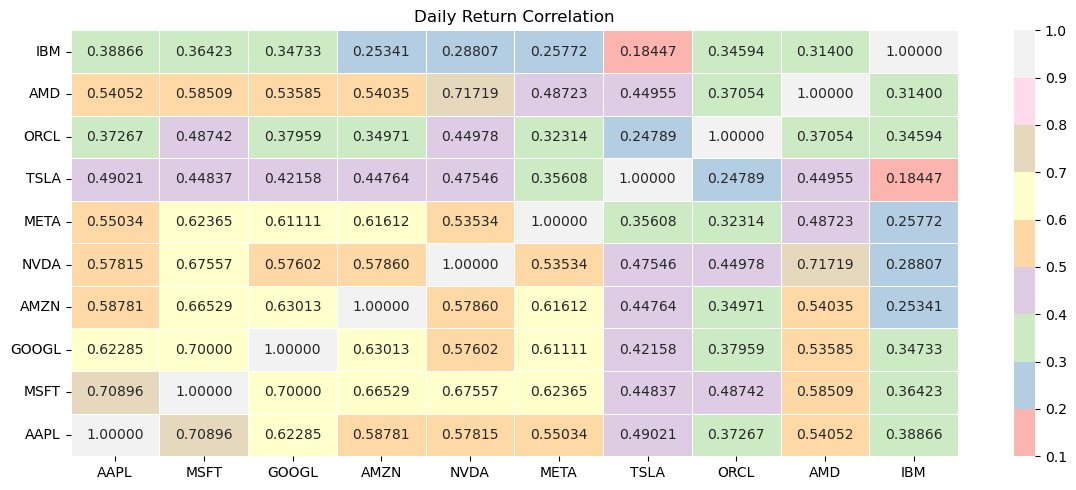

In [41]:
#Heatmap Static
plt.figure(figsize=(12, 5))

corr_matrix_map = sns.heatmap(corr_matrix, cmap='Pastel1', annot=True, fmt=".5f", vmin=0.1, vmax=1, linewidths=0.5, cbar=True)
corr_matrix_map.invert_yaxis()

plt.title('Daily Return Correlation')
plt.tight_layout()

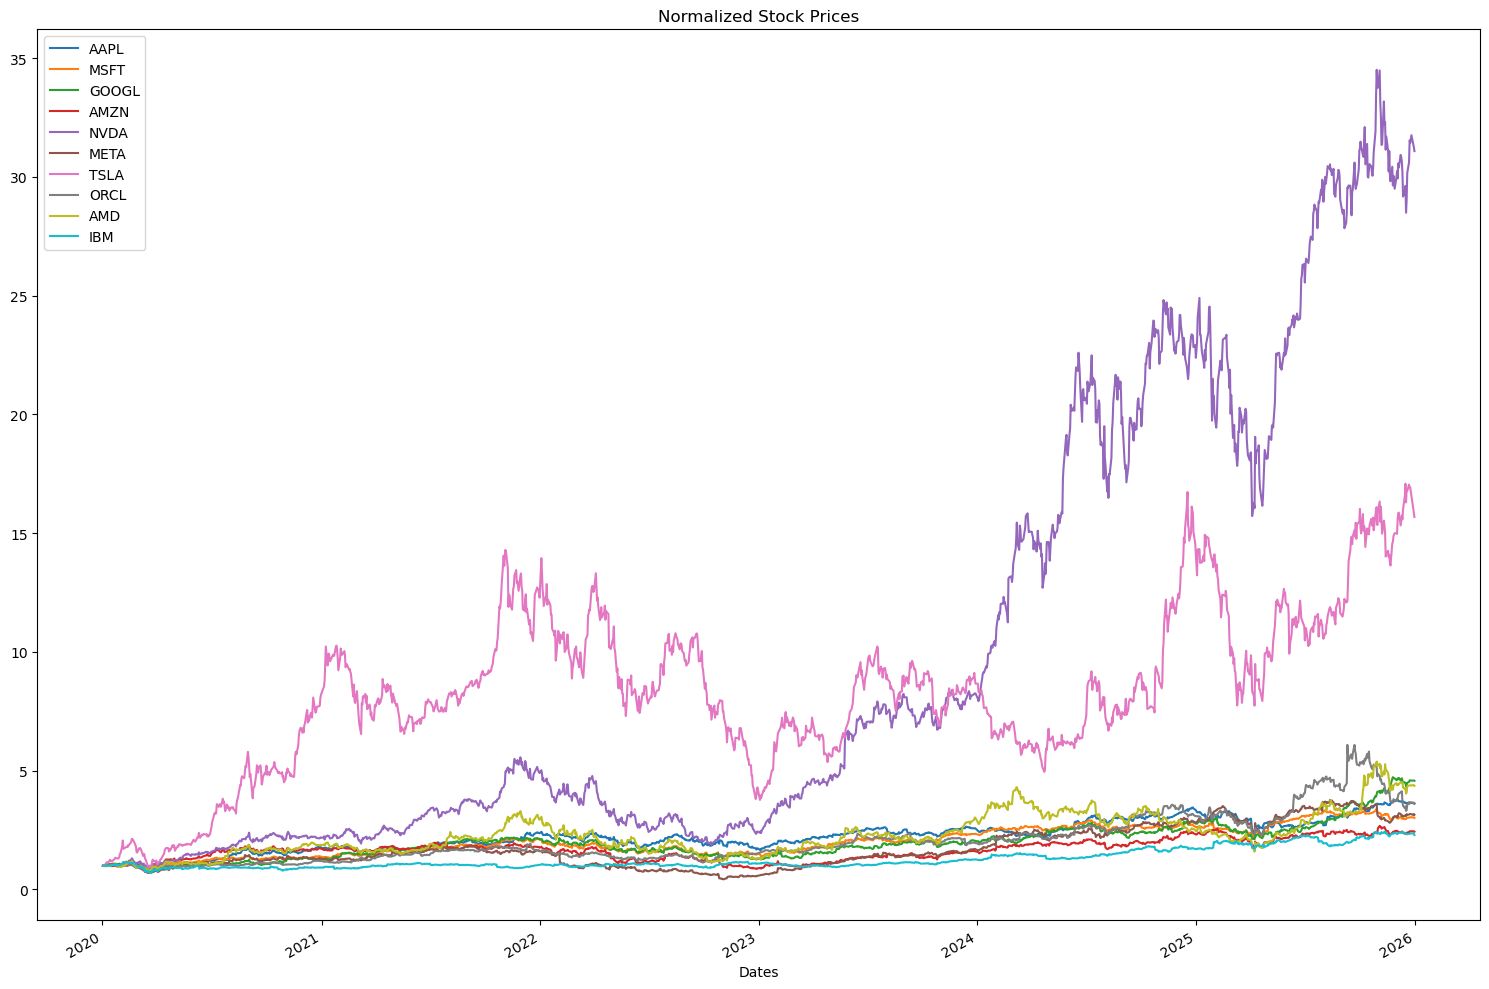

In [42]:
# Normalized Stocks graph static

normed_stocks = stocks / stocks.iloc[0]

normed_stocks_fig = normed_stocks.plot(figsize=(15, 10), legend=True)
normed_stocks_fig.set_title('Normalized Stock Prices')
normed_stocks_fig.set_xlabel('Dates')
plt.tight_layout()
plt.show()

### Log Returns

We can now calculate log returns, since most technical analyses require detrending/normalizing the time series, and using log returns is useful.

In [43]:
log_return = np.log(stocks/stocks.shift(1))
log_return.head()

,AAPL,MSFT,GOOGL,AMZN,NVDA,META,TSLA,ORCL,AMD,IBM
date,,,,,,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,-0.009769,-0.012530,-0.005128,-0.012192,-0.016807,-0.005305,0.029207,-0.003528,-0.010236,-0.007995
2020-01-06,0.007903,0.002581,0.026239,0.014718,0.005072,0.018658,0.019118,0.005195,-0.004330,-0.001794
2020-01-07,-0.004681,-0.009160,-0.001862,0.002100,0.011735,0.002161,0.038134,0.002218,-0.002897,0.000624
2020-01-08,0.015958,0.015803,0.007000,-0.007792,0.001665,0.010087,0.048074,-0.000554,-0.008743,0.008314


This table describes the dataset from log returns - the count, mean, standard deviation, the extemes and the quartiles.

In [44]:
log_return.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
AAPL,1507.0,0.000854,0.019991,-0.137713,-0.008259,0.001094,0.011399,0.142617
MSFT,1507.0,0.000731,0.018614,-0.159453,-0.007963,0.000952,0.010345,0.132929
GOOGL,1507.0,0.001009,0.020454,-0.123627,-0.009463,0.001697,0.011569,0.097348
AMZN,1507.0,0.000590,0.022472,-0.151434,-0.011172,0.000768,0.012871,0.126920
NVDA,1507.0,0.002280,0.033317,-0.203813,-0.015628,0.003079,0.021506,0.218022
META,1507.0,0.000761,0.027856,-0.306391,-0.011682,0.000965,0.014150,0.209307
TSLA,1507.0,0.001826,0.041813,-0.236518,-0.020331,0.001647,0.023568,0.204491
ORCL,1507.0,0.000852,0.024055,-0.148394,-0.008851,0.001268,0.010640,0.307108
AMD,1507.0,0.000977,0.033693,-0.158280,-0.017211,0.000000,0.019786,0.213663
IBM,1507.0,0.000550,0.017328,-0.137546,-0.007373,0.001007,0.008473,0.121901


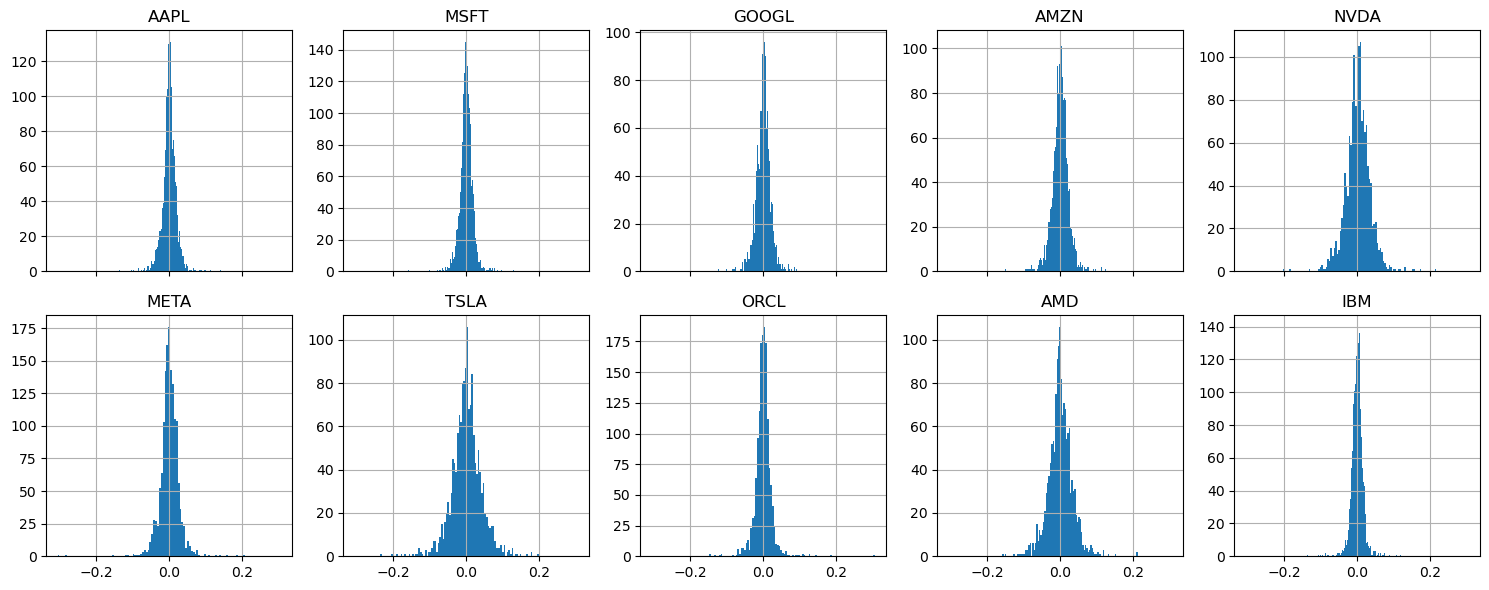

In [45]:
# Static Histogram plots

hist_assets = log_return.shape[1]
hist_cols = 5
hist_rows = int(np.ceil(hist_assets / hist_cols))

hist_plots, axes = plt.subplots(hist_rows, hist_cols, figsize=(15, 3 * hist_rows), sharex=True)

axes = axes.flatten()

for i, col in enumerate(log_return.columns):
    axes[i].hist(log_return[col].dropna(), bins=100)
    axes[i].set_title(col)
    axes[i].grid(True)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

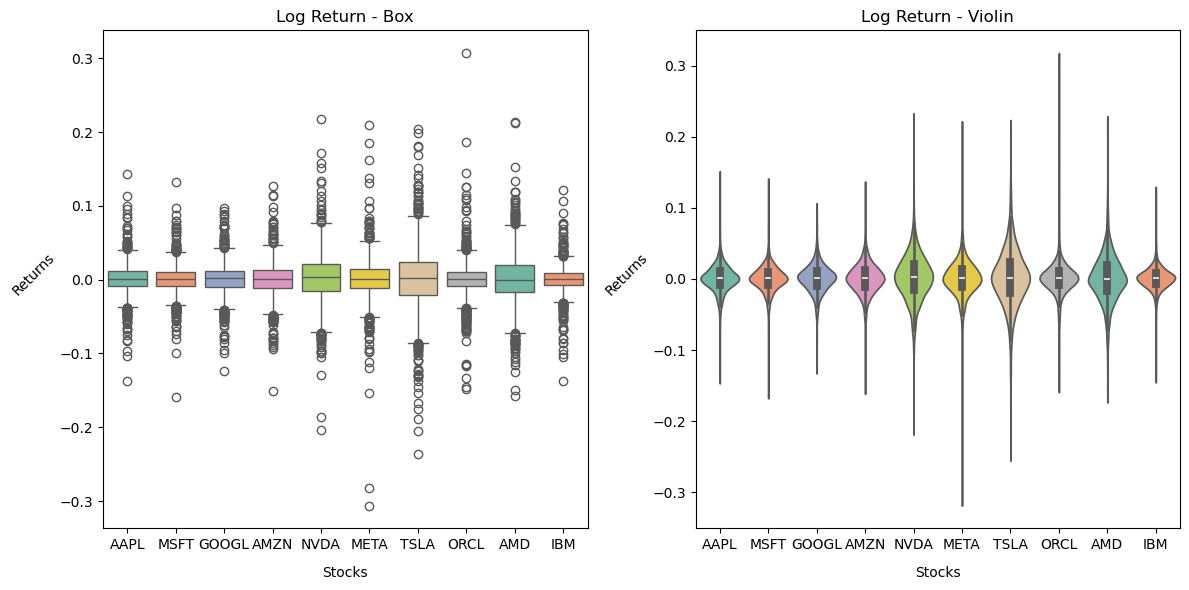

In [46]:
# Static Box and Violin Plots of Log Return
log_return_melt = log_return.melt(value_name='Return', var_name='Stock')

box_violin_figure, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.boxplot(data=log_return_melt, 
            x='Stock',
            y='Return',
            palette='Set2',hue='Stock',ax=axes[0])

axes[0].set_title('Log Return - Box')
axes[0].set_xlabel('Stocks',rotation = 0, labelpad=10)
axes[0].set_ylabel('Returns',rotation = 45, labelpad=15)

sns.violinplot(data=log_return_melt,
               x='Stock',
               y='Return',
               palette='Set2',hue='Stock',ax=axes[1])

axes[1].set_title('Log Return - Violin')
axes[1].set_xlabel('Stocks',rotation = 0, labelpad=10)
axes[1].set_ylabel('Returns',rotation = 45, labelpad=15)

plt.tight_layout()

### Covariance Matrix

Let's also calculate the covariance matrix of the log returns. Covariance measures how two variables change or, in our case, move together. 

In [47]:
log_return.cov()

,AAPL,MSFT,GOOGL,AMZN,NVDA,META,TSLA,ORCL,AMD,IBM
AAPL,0.000400,0.000264,0.000256,0.000265,0.000388,0.000305,0.000415,0.000183,0.000367,0.000135
MSFT,0.000264,0.000346,0.000267,0.000279,0.000421,0.000321,0.000354,0.000221,0.000369,0.000118
GOOGL,0.000256,0.000267,0.000418,0.000291,0.000396,0.000346,0.000365,0.000191,0.000371,0.000123
AMZN,0.000265,0.000279,0.000291,0.000505,0.000437,0.000384,0.000422,0.000195,0.000412,0.000100
NVDA,0.000388,0.000421,0.000396,0.000437,0.001110,0.000495,0.000672,0.000369,0.000811,0.000167
META,0.000305,0.000321,0.000346,0.000384,0.000495,0.000776,0.000415,0.000220,0.000455,0.000124
TSLA,0.000415,0.000354,0.000365,0.000422,0.000672,0.000415,0.001748,0.000258,0.000641,0.000137
ORCL,0.000183,0.000221,0.000191,0.000195,0.000369,0.000220,0.000258,0.000579,0.000307,0.000147
AMD,0.000367,0.000369,0.000371,0.000412,0.000811,0.000455,0.000641,0.000307,0.001135,0.000185
IBM,0.000135,0.000118,0.000123,0.000100,0.000167,0.000124,0.000137,0.000147,0.000185,0.000300


Since there are typically 252 trading days in a year, we can mulitply 252 with the daily covariance. This helps us understand the long-term relationships between stocks in the portfolio and for making decisions based on annual performance.

In [48]:
# Annual Covariance 
annual_covar = log_return.cov() * 252
annual_covar

,AAPL,MSFT,GOOGL,AMZN,NVDA,META,TSLA,ORCL,AMD,IBM
AAPL,0.100713,0.066629,0.064430,0.066749,0.097713,0.076745,0.104622,0.046024,0.092367,0.034131
MSFT,0.066629,0.087309,0.067294,0.070255,0.106187,0.081008,0.089295,0.055694,0.092990,0.029803
GOOGL,0.064430,0.067294,0.105423,0.073235,0.099715,0.087170,0.091908,0.048179,0.093603,0.031122
AMZN,0.066749,0.070255,0.073235,0.127260,0.110040,0.096741,0.106359,0.049108,0.103797,0.025102
NVDA,0.097713,0.106187,0.099715,0.110040,0.279721,0.124654,0.169366,0.093052,0.204253,0.042202
META,0.076745,0.081008,0.087170,0.096741,0.124654,0.195539,0.104651,0.055433,0.114724,0.031360
TSLA,0.104622,0.089295,0.091908,0.106359,0.169366,0.104651,0.440588,0.065038,0.161507,0.034486
ORCL,0.046024,0.055694,0.048179,0.049108,0.093052,0.055433,0.065038,0.145820,0.077314,0.037097
AMD,0.092367,0.092990,0.093603,0.103797,0.204253,0.114724,0.161507,0.077314,0.286075,0.046709
IBM,0.034131,0.029803,0.031122,0.025102,0.042202,0.031360,0.034486,0.037097,0.046709,0.075668


And again, we can create a heatmap. But this time, the diagonal of covariance doesn't represent 1s, like the correlation matrix earlier. Instead, the diagonal of covariance matrix represents the variance of each individual log return of each stock.

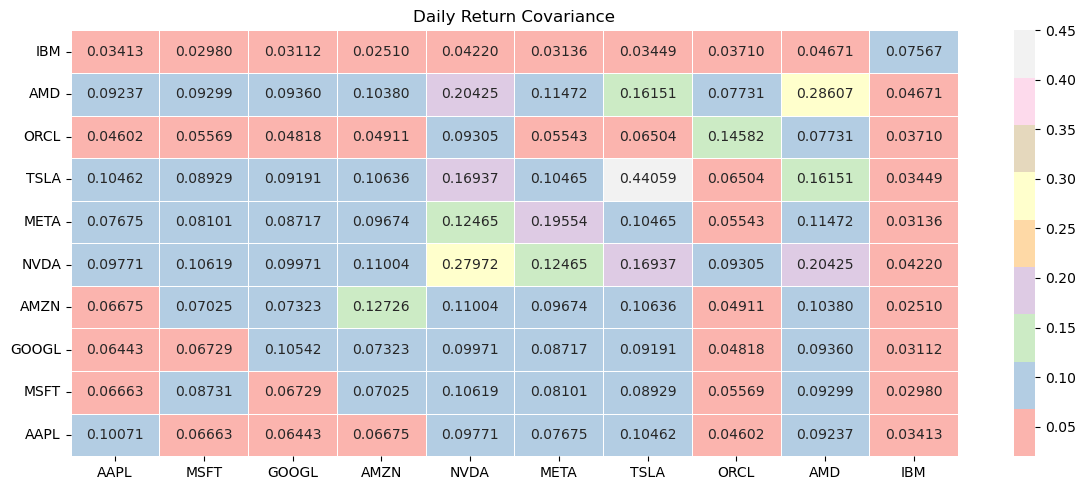

In [49]:
# Static Annual Covariance Heatmap
plt.figure(figsize=(12, 5))

corr_matrix_map = sns.heatmap(annual_covar, cmap='Pastel1', annot=True, fmt=".5f", vmin=0.02, vmax=0.45, linewidths=0.5, cbar=True)
corr_matrix_map.invert_yaxis()

plt.title('Daily Return Covariance')
plt.tight_layout()

### Covariance v/s Correlation Matrix

#### Covariance Matrix
- Covariance is how strongly two returns move, independent of scale.
- Three scales of covariance:
    - Positive covariance means they tend to move in the same direction.
    - Negative covariance means they tend to move in opposite directions.
    - Zero covariance means there's no consistent relationship.
- In simple terms, covariance tells us <b>how much movement actually matters</b>.
$$\text{Cov}(X,Y) = \frac{\sum_{i=1}^{n} (X_{i} - \bar{X})(Y_{i} - \bar{Y})}{n-1}$$
where $X_{i}$ is the $\text{i}^\text{th}$ observation of the first asset <br>
$\bar{X}$ is the mean of the first asset <br>
$Y_{i}$ is the $\text{i}^\text{th}$ observation of the second asset <br>
$\bar{Y}$ is the mean of the second asset <br>
$n$ is the number of observations

#### Correlation Matrix
- Correlation is how two returns move together, in absolute terms.
- The correlation variable is always between $–1$ and $1$.
- In simple terms, correlation tells us <b>who moves with whom</b>.
$$ \rho_{xy}= \frac{Cov(x,y)}{\sigma_{x} * \sigma_{y}} $$
where $Cov(x,y)$ is the covariance between the two stocks <br>
$\sigma_{x}$ is the standard deviation of stock $x$ <br>
$\sigma_{y}$ is the standard deviation of stock $y$

### Risk Contribution

We will use risk contribution analysis to see how much each asset contributes to the portfolio's risk, rather than its return. We use log returns, and the covariance matrix is used to see how each asset behaves together. The portfolio's risk is measured in terms of variance and volatility.

We use these formulas:

- Total portfolio variance ($\sigma_{p}^{2}$)
  $$\sigma_{p}^{2} = w^{T} \Sigma w$$
  where $\sigma_{p}^{2}$ is the total risk of the portfolio <br>
  $w$ is the weight vector, i.e., it contains the proportion of capital invested in each asset <br>
  $w^{T}$ is the transpose of the weight vector ($w$) <br>
  $\Sigma$ is the covariance matrix
  
- Marginal Risk Contribution (MRC) of an asset $i$ to a portfolio is the change in total portfolio risk $\sigma_{p}$ resulting from a small change in that asset's weight $w_{i}$
  $$MRC_{i} = \frac{(\Sigma w)_i}{\sigma_p}$$
    where $(\Sigma w)_i$ is the $i^{th}$ element of the vector when covariance matrix ($\Sigma$) and weight vector ($w$) are multiplied <br>
    $\sigma_p$ is the portfolio standard deviation

- Total Risk Contribution (TRC) of an asset $i$ is the Marginal Risk Contribution (MRC) of an asset $i$ multiplied with the change in that asset's weight $w_{i}$
  $$TRC_{i} = w_{i} * MRC_{i}$$

Let's define our weight vector and calculate our portfolio variance and volatility.

In [50]:
n_assets = log_return.shape[1]
weights = np.ones(n_assets) / n_assets

cov_matrix = log_return.cov()
portfolio_variance = weights.T @ cov_matrix.values @ weights
portfolio_volatility = np.sqrt(portfolio_variance)

portfolio_variance, portfolio_volatility

(0.00036046978768245353, 0.01898604191722049)

Calculate Marginal Risk and Total Risk Contribution

In [51]:
marginal_risk = cov_matrix.values @ weights
mrc = marginal_risk / portfolio_volatility

trc = weights * mrc

Let's make a table of risk contribution

In [52]:
risk_contribution_table = pd.DataFrame({
    'Weight': weights,
    'MRC': mrc,
    'TRC': trc
}, index=log_return.columns)

risk_contribution_table

,Weight,MRC,TRC
AAPL,0.1,0.015678,0.001568
MSFT,0.1,0.015602,0.001560
GOOGL,0.1,0.015928,0.001593
AMZN,0.1,0.017319,0.001732
NVDA,0.1,0.027733,0.002773
META,0.1,0.020233,0.002023
TSLA,0.1,0.028589,0.002859
ORCL,0.1,0.014061,0.001406
AMD,0.1,0.026614,0.002661
IBM,0.1,0.008103,0.000810


We can calculate the percentage risk contribution and plot the bar graph

Text(0.5, 1.0, 'Portfolio Risk Contribution by Asset')

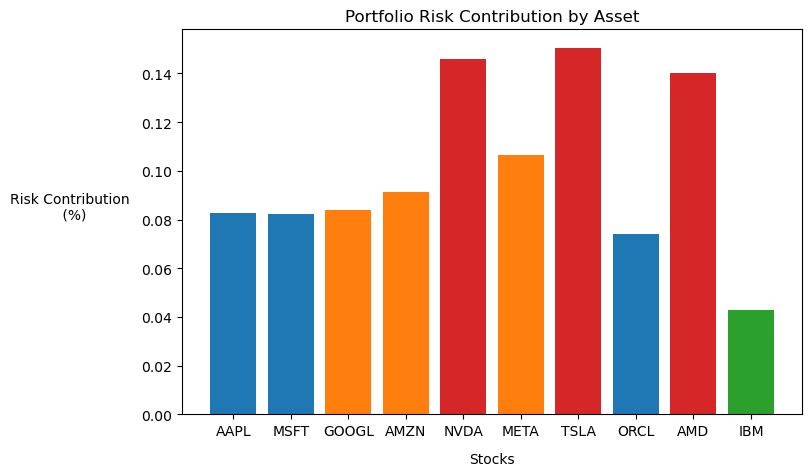

In [53]:
# TRC Bar Graph Static
trc_percent = trc / trc.sum()

plt.figure(figsize=(8, 5))
plt.bar(log_return.columns, trc_percent, color=['tab:blue','tab:blue','tab:orange','tab:orange', \
                                            'tab:red','tab:orange','tab:red','tab:blue','tab:red','tab:green'])
plt.xlabel('Stocks',labelpad=10)
plt.ylabel('Risk Contribution \n (%)',rotation=0,labelpad=50)
plt.title('Portfolio Risk Contribution by Asset')

### Single Simulation Experiment

We observed what the assets look like. Now, we can answer the question: What happens if one actually invests in one? 

In this section, we will generate one random set of portfolio weights, apply them to asset returns, and see what the risk/return ratio is.
> Before we apply simulations for thousands of portfolios, we should at least experiment with one.

1. To ensure reproducibility, we first generate a random seed. Then we create random weights for asset allocation, assuming the portfolio contains 10 assets, which are our 10 tech stocks.

In [54]:
np.random.seed(50)

print('Stocks')
print(stocks.columns)
print('\n')

Stocks
Index(['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', 'ORCL', 'AMD',
       'IBM'],
      dtype='object')




2. Now, we create random weights for asset allocation for our ten assets. These weights should be normalized to make sure the total allocation equals the entire investment.

3. We calculate the expected portfolio return and variance. These values will allow us to calculate the <b>Sharpe Ratio</b>, which tells us the risk-adjusted returns by scaling average excess returns by their volatility.

In [55]:
# Creating Random Weights
weights = np.array(np.random.random(10))
print('Creating Random Weights \n',weights)
print('\n')

# Rebalance Weights
weights = weights / np.sum(weights)
print('Rebalance weights to sum to 1.0 \n', weights)
print('\n')

# Expected Return
exp_return = np.sum(log_return.mean() * weights) * 252
print('Expected Portfolio Return \n', exp_return)
print('\n')

# Expected Variance
exp_vol = np.sqrt(np.dot(weights.T, np.dot(log_return.cov() * 252, weights)))
print('Expected Volatility \n',exp_vol)
print('\n')

# Sharpe Ratio
sharpe_ratio = exp_return/exp_vol
print('Sharpe Ratio')
print(sharpe_ratio)

Creating Random Weights 
 [0.49460165 0.2280831  0.25547392 0.39632991 0.3773151  0.99657423
 0.4081972  0.77189399 0.76053669 0.31000935]


Rebalance weights to sum to 1.0 
 [0.09893982 0.04562561 0.05110485 0.0792816  0.07547789 0.19935411
 0.08165552 0.15440921 0.1521373  0.06201408]


Expected Portfolio Return 
 0.25287194332662316


Expected Volatility 
 0.31440897229920867


Sharpe Ratio
0.8042771218563587


4. This step is an additional step. In the previous section, we learned about marginal and total risk contribution, which tells us how much each asset contributes to the portfolio's risk. We can apply those formulas from above to get the risk contribution percentage of all ten stocks.

In [56]:
# Marginal Risk Contribution
mrc = np.dot(log_return.cov() * 252, weights) / exp_vol

# Total Risk Contribution
rc = weights * mrc

# Normalize to percentage contribution
rc_percent = rc / np.sum(rc)

risk_contribution = pd.Series(rc_percent, index=stocks.columns)
print('Risk contribution percentage \n', risk_contribution)

Risk contribution percentage 
 AAPL     0.076149
MSFT     0.034910
GOOGL    0.039630
AMZN     0.068050
NVDA     0.103982
META     0.218420
TSLA     0.110630
ORCL     0.114673
AMD      0.209657
IBM      0.023900
dtype: float64


### Multiple Simulations

Now that it works for a single simulation, let's run it multiple times. We are using the Monte Carlo Method, which relies on random sampling to approximate complex mathematical problems. By repeatedly sampling the distribution of possible outcomes, we can estimate the characteristics of the overall distribution. It gives us insight into the portfolio's performance.

We are running a couple of thousand simulations to test the portfolios (it can be modified to a higher or lower number). And we initialize arrays for storing the weights, expected return, expected variance, and Sharpe ratio. Then, we pick 10 random allocations and rebalance them to 1. Then, save the weights in each row of the weights array. Similarly, calculate the expected return, expected volatility/variance, and Sharpe ratio and store them in their respective arrays.

In [57]:
# Number of simulations
num_sim = 100000

# Number of assets, which is our 10 stocks
num_assets = len(stocks.columns)

# Initialize all arrays
weights_arr = np.zeros((num_sim, num_assets))
exp_return_arr = np.zeros(num_sim)
exp_vol_arr = np.zeros(num_sim)
sharpe_ratio_arr = np.zeros(num_sim)

# Insert the values
for i in range(num_sim):

    # Create Random Weights
    weights = np.array(np.random.random(10))

    # Rebalance Weights
    weights = weights / np.sum(weights)
    
    # Save and assign the Weights array
    weights_arr[i,:] = weights

    # Expected Return array
    exp_return_arr[i] = np.sum((log_return.mean() * weights) * 252)

    # Expected Volatility/Variance array
    exp_vol_arr[i] = np.sqrt(np.dot(weights.T, np.dot(log_return.cov() * 252, weights)))

    # Sharpe Ratio array
    sharpe_ratio_arr[i] = exp_return_arr[i]/exp_vol_arr[i]

In [58]:
max_sharpe = sharpe_ratio_arr.max()
max_sharpe_index = sharpe_ratio_arr.argmax()
max_sharpe, max_sharpe_index

(1.0701475309797495, 78363)

In [59]:
weights_arr[max_sharpe_index,:]

array([0.04868977, 0.00074273, 0.23950404, 0.0251439 , 0.2778592 ,
       0.00384549, 0.08440639, 0.0019468 , 0.008782  , 0.30907968])

In [60]:
max_sharpe_return = exp_return_arr[max_sharpe_index]
max_sharpe_vol = exp_vol_arr[max_sharpe_index]

In [69]:
# Scatterplot for Return and Volatility
data = pd.DataFrame({'Volatility': exp_vol_arr, 'Return': exp_return_arr, 'Sharpe Ratio': sharpe_ratio_arr})
max_sharpe_data = pd.DataFrame({'vol': [max_sharpe_vol], 'ret': [max_sharpe_return]})

scatter = data.hvplot.scatter(x='Volatility', y='Return', c='Sharpe Ratio', \
    cmap='plasma', width=900, height=600, colorbar=True, padding=0.1)
max_sharpe = max_sharpe_data.hvplot.scatter(x='vol', y='ret', color='red', line_color='black', s=25)

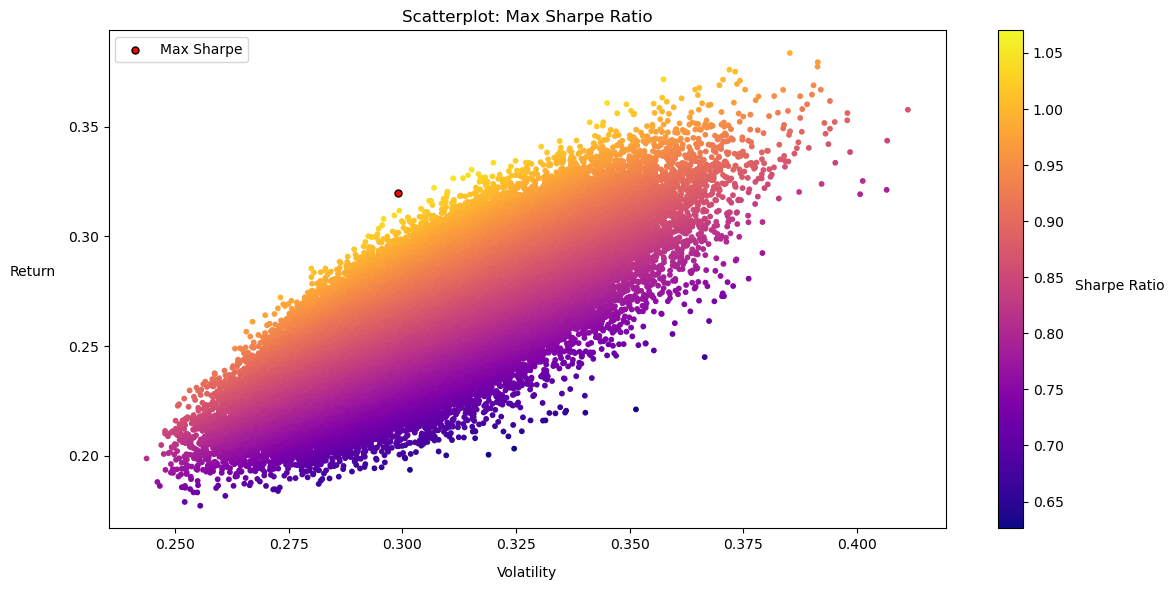

In [70]:
# Static Scatterplot for Return and Volatility

plt.figure(figsize=(12, 6))

plots = plt.scatter(
    exp_vol_arr,
    exp_return_arr,
    c=sharpe_ratio_arr,
    cmap='plasma',
    s=10
)

plt.scatter(
    max_sharpe_vol,
    max_sharpe_return,
    color='red',
    edgecolors='black',
    s=25,
    label='Max Sharpe'
)

plt.xlabel('Volatility',rotation=0, labelpad=10)
plt.ylabel('Return',rotation=0, labelpad=25)
plt.title('Scatterplot: Max Sharpe Ratio')
cbar = plt.colorbar(plots)
cbar.set_label('Sharpe Ratio', rotation=0, labelpad=40)
plt.legend()
plt.tight_layout()

### Mathematical Optmization

Rather than guessing and checking, we can use mathematical optimization methods to find out what are the better allocation weights that are efficient for our model.

In [71]:
# Expected Return, Volatility, and Sharpe Ratio Function
def get_return_vol_sr(weights):
    weights = np.array(weights)
    exp_return = np.sum((log_return.mean() * weights) * 252)
    exp_vol = np.sqrt(np.dot(weights.T, np.dot(log_return.cov() * 252, weights)))
    sharpe_ratio = exp_return / exp_vol

    return np.array([exp_return, exp_vol, sharpe_ratio])

As optimization will be used as a minimization function, we actually want to maximize the Sharpe Ratio, we will need to turn it negative so we can minimize the negative Sharpe (same as maximizing the positive Sharpe)

In [72]:
# Maximizes Sharpe Ratio
def negative_sharpe(weights):
    return get_return_vol_sr(weights)[2] * -1

# Enforces the fully invested portfolio
def check_sum(weights):
    return np.sum(weights) - 1

# By convention of the 'minimize' function, it should return zero for conditions
cons = ({'type':'eq','fun': check_sum})

# Each asset weight is between 0 and 1
bounds = ((0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1))

# Put random percentage into the initial capital allocation
init_guess = np.random.random(num_assets)
init_guess /= np.sum(init_guess)

# Use Sequential Least Squares Programming
opt_results = minimize(negative_sharpe, init_guess, method='SLSQP', bounds=bounds, constraints=cons)
opt_results

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: -1.1247214647900803
       x: [ 0.000e+00  0.000e+00  1.479e-01  9.918e-18  5.521e-01
            1.073e-16  9.254e-02  1.504e-03  0.000e+00  2.059e-01]
     nit: 8
     jac: [ 6.057e-02  1.638e-01 -7.314e-04  2.862e-01  5.229e-05
            2.608e-01 -4.254e-04 -3.531e-04  5.345e-01  5.736e-04]
    nfev: 89
    njev: 8

In [73]:
opt_results.x

array([0.00000000e+00, 0.00000000e+00, 1.47919085e-01, 9.91770669e-18,
       5.52101037e-01, 1.07333623e-16, 9.25448155e-02, 1.50379744e-03,
       0.00000000e+00, 2.05931266e-01])

In [74]:
get_return_vol_sr(opt_results.x)

array([0.42633701, 0.37906008, 1.12472146])

### Efficient Frontier

The efficient frontier is a core concept of Modern Portfolio Theory (MPT). It is the set of optimal portfolios that delivers the maximum expected return for a given level of risk, or equivalently, the lowest risk for a given level of expected return. Portfolios that lie below the frontier are sub-optimal or inefficient because the return is not enough for the level of risk.

In [76]:
# Find out what the maximum and minimum return for the scatterplot is 
# to create a linspace number of points to calculate x on

min_return = scatter['Return'].min()
max_return = scatter['Return'].max()

frontier_y = np.linspace(0,0.5,100)

def minimize_volatility(weights):
    return  get_return_vol_sr(weights)[1]

In [77]:
frontier_volatility = []

for possible_return in frontier_y:
    cons = ({'type':'eq','fun': check_sum},
            {'type':'eq','fun': lambda w: get_return_vol_sr(w)[0] - possible_return})
    
    result = minimize(minimize_volatility, init_guess, method='SLSQP', bounds=bounds, constraints=cons)
    
    frontier_volatility.append(result['fun'])

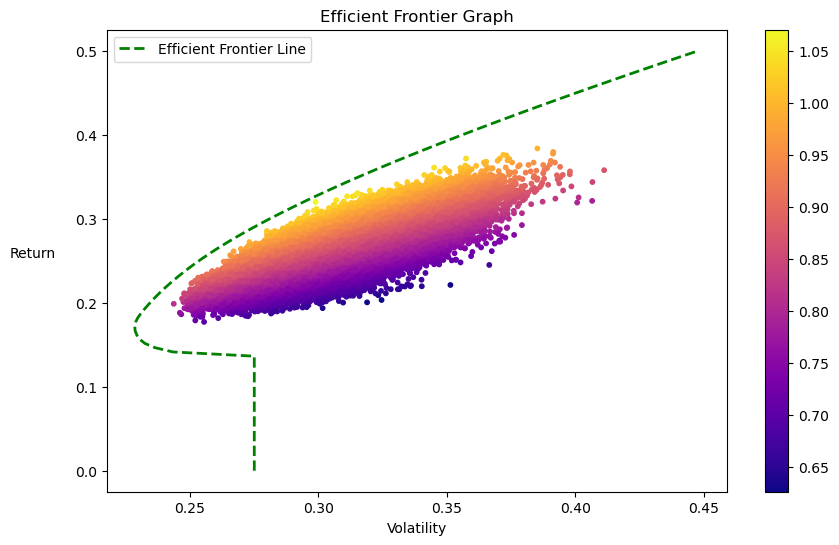

In [78]:
# Static Efficient Frontier Graph

plt.figure(figsize=(10,6))

plots = plt.scatter(
    exp_vol_arr,
    exp_return_arr,
    c=sharpe_ratio_arr,
    cmap='plasma',
    s=10
)

plt.colorbar(plots)

plt.plot(
    frontier_volatility,
    frontier_y,
    'g--',
    linewidth=2,
    label='Efficient Frontier Line'
)

plt.xlabel('Volatility')
plt.ylabel('Return',rotation=0,labelpad=30)
plt.title('Efficient Frontier Graph')
plt.legend()
plt.show()

### Tangency Portfolio

Tangency portfolio is the portfolio with the maximum Sharpe Ratio.

In [80]:
cons = ({'type': 'eq', 'fun': check_sum},)

result = minimize(
    negative_sharpe,
    init_guess,
    method='SLSQP',
    bounds=bounds,
    constraints=cons
)

tangent_return, tangent_vol, tangent_sharpe = get_return_vol_sr(result.x)

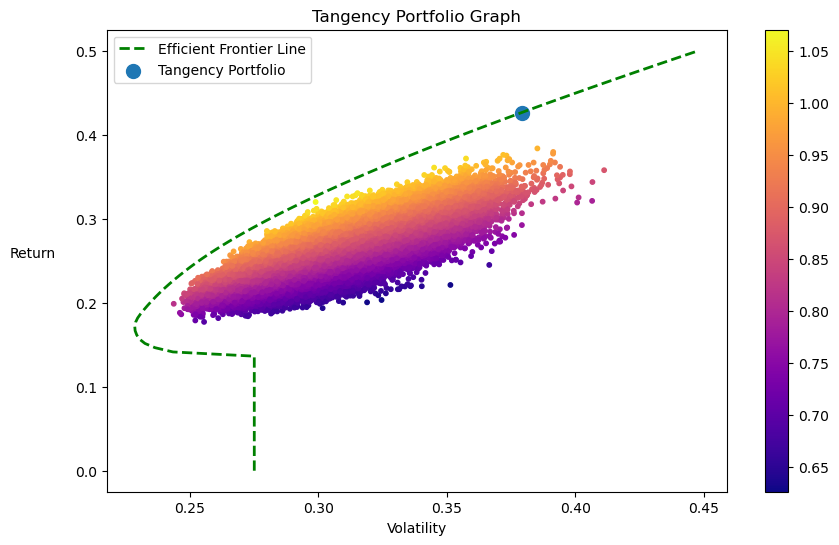

In [81]:
# Tangency Portfolio Graph Static

plt.figure(figsize=(10,6))

plots = plt.scatter(
    exp_vol_arr,
    exp_return_arr,
    c=sharpe_ratio_arr,
    cmap='plasma',
    s=10
)

plt.colorbar(plots)

plt.plot(
    frontier_volatility,
    frontier_y,
    'g--',
    linewidth=2,
    label='Efficient Frontier Line'
)

plt.scatter(
    tangent_vol,
    tangent_return,
    marker='o',
    s=100,
    label='Tangency Portfolio'
)

plt.xlabel('Volatility')
plt.ylabel('Return',rotation=0,labelpad=30)
plt.title('Tangency Portfolio Graph')
plt.legend()
plt.show()

## Section A — Risk Parity Portfolio

### Risk Parity Portfolio

The **Risk Parity** approach allocates weights so that every asset contributes *equally* to total portfolio risk, rather than maximising return.

We minimise the variance of percentage risk contributions across all assets:

$$\min_w \sum_{i} \left( RC_i^{\%} - \frac{1}{N} \right)^2$$

where $RC_i^{\%} = \dfrac{w_i \cdot MRC_i}{\sigma_p}$

In [82]:
# Risk Parity helper functions

cov_annual   = log_return.cov() * 252
n_assets_rp  = len(stocks.columns)

def compute_trc_percent(weights, cov):
    """Return % risk contribution array for given weights and cov matrix."""
    weights  = np.array(weights)
    port_vol = np.sqrt(weights @ cov @ weights)
    mrc      = (cov @ weights) / port_vol
    trc      = weights * mrc
    return trc / trc.sum()

def risk_parity_objective(weights, cov):
    """Minimise variance of % risk contributions → equal risk per asset."""
    return np.var(compute_trc_percent(weights, cov))

# ── Optimise ──────────────────────────────────────────────────────────────────
init_rp   = np.ones(n_assets_rp) / n_assets_rp
bounds_rp = tuple((0.01, 1.0) for _ in range(n_assets_rp))
cons_rp   = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})

rp_result  = minimize(risk_parity_objective, init_rp,
                      args=(cov_annual,), method='SLSQP',
                      bounds=bounds_rp, constraints=cons_rp)

rp_weights  = rp_result.x
rp_return, rp_vol, rp_sharpe = get_return_vol_sr(rp_weights)

for ticker, w in zip(stocks.columns, rp_weights):
    print(f"  {ticker}: {w:.4f}")
print(f"\nReturn: {rp_return:.4f}  |  Volatility: {rp_vol:.4f}  |  Sharpe: {rp_sharpe:.4f}")

  AAPL: 0.1082
  MSFT: 0.1089
  GOOGL: 0.1061
  AMZN: 0.0988
  NVDA: 0.0646
  META: 0.0856
  TSLA: 0.0647
  ORCL: 0.1156
  AMD: 0.0677
  IBM: 0.1798

Return: 0.2347  |  Volatility: 0.2729  |  Sharpe: 0.8602


### Strategy Comparison: Equal-Weight vs Max Sharpe vs Risk Parity

We compare how risk is distributed under each strategy and summarise key performance metrics side-by-side.

In [86]:
# Comparison table
eq_weights = np.ones(n_assets_rp) / n_assets_rp
ms_weights = opt_results.x

eq_trc_pct = compute_trc_percent(eq_weights, cov_annual)
ms_trc_pct = compute_trc_percent(ms_weights, cov_annual)
rp_trc_pct = compute_trc_percent(rp_weights, cov_annual)

eq_ret, eq_vol_val, eq_sr = get_return_vol_sr(eq_weights)
ms_ret, ms_vol_val, ms_sr = get_return_vol_sr(ms_weights)

summary_df = pd.DataFrame({
    'Strategy':   ['Equal Weight', 'Max Sharpe', 'Risk Parity'],
    'Return':     [eq_ret,      ms_ret,      rp_return],
    'Volatility': [eq_vol_val,  ms_vol_val,  rp_vol],
    'Sharpe':     [eq_sr,       ms_sr,       rp_sharpe],
}).set_index('Strategy').round(4)

summary_df

,Return,Volatility,Sharpe
Strategy,,,
Equal Weight,0.2629,0.3014,0.8721
Max Sharpe,0.4263,0.3791,1.1247
Risk Parity,0.2347,0.2729,0.8602


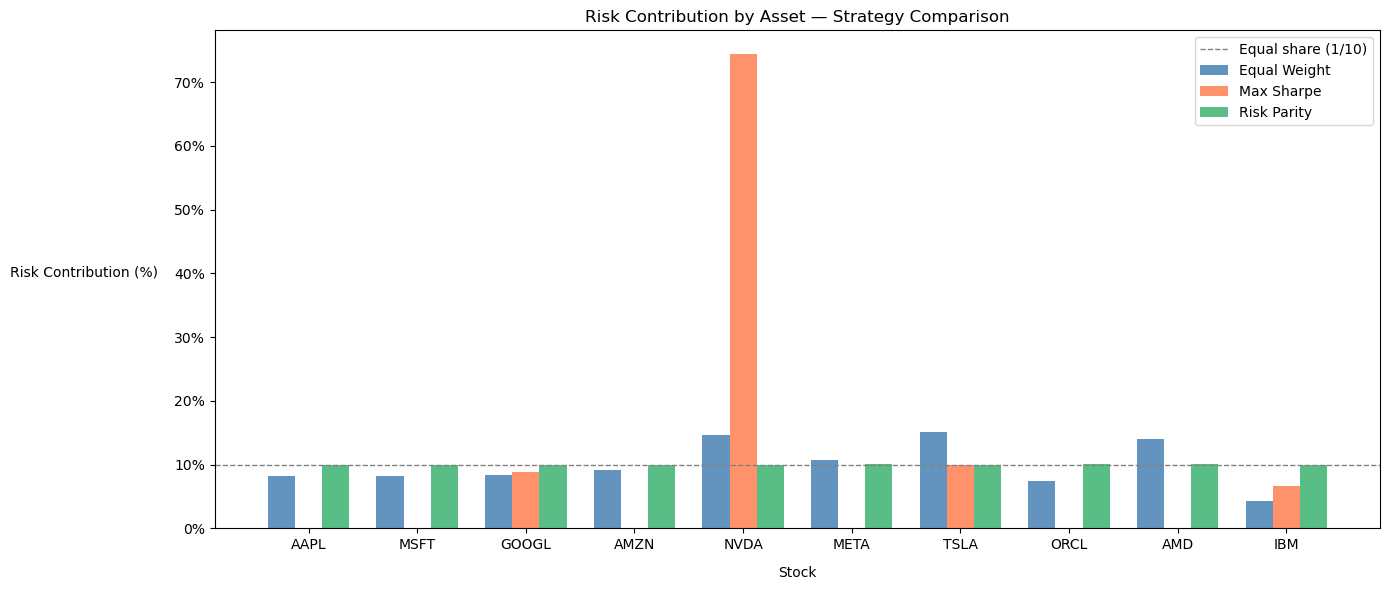

In [87]:
# Grouped bar: % Risk contribution by strategy
tickers = list(stocks.columns)
x       = np.arange(len(tickers))
w_bar   = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - w_bar, eq_trc_pct, w_bar, label='Equal Weight',  color='steelblue',       alpha=0.85)
ax.bar(x,         ms_trc_pct, w_bar, label='Max Sharpe',    color='coral',           alpha=0.85)
ax.bar(x + w_bar, rp_trc_pct, w_bar, label='Risk Parity',   color='mediumseagreen',  alpha=0.85)

ax.axhline(1 / n_assets_rp, color='grey', linestyle='--', linewidth=1,
           label=f'Equal share (1/{n_assets_rp})')

ax.set_xticks(x)
ax.set_xticklabels(tickers)
ax.set_xlabel('Stock', labelpad=10)
ax.set_ylabel('Risk Contribution (%)', rotation=0, labelpad=65)
ax.set_title('Risk Contribution by Asset — Strategy Comparison')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.legend()
plt.tight_layout()
plt.show()

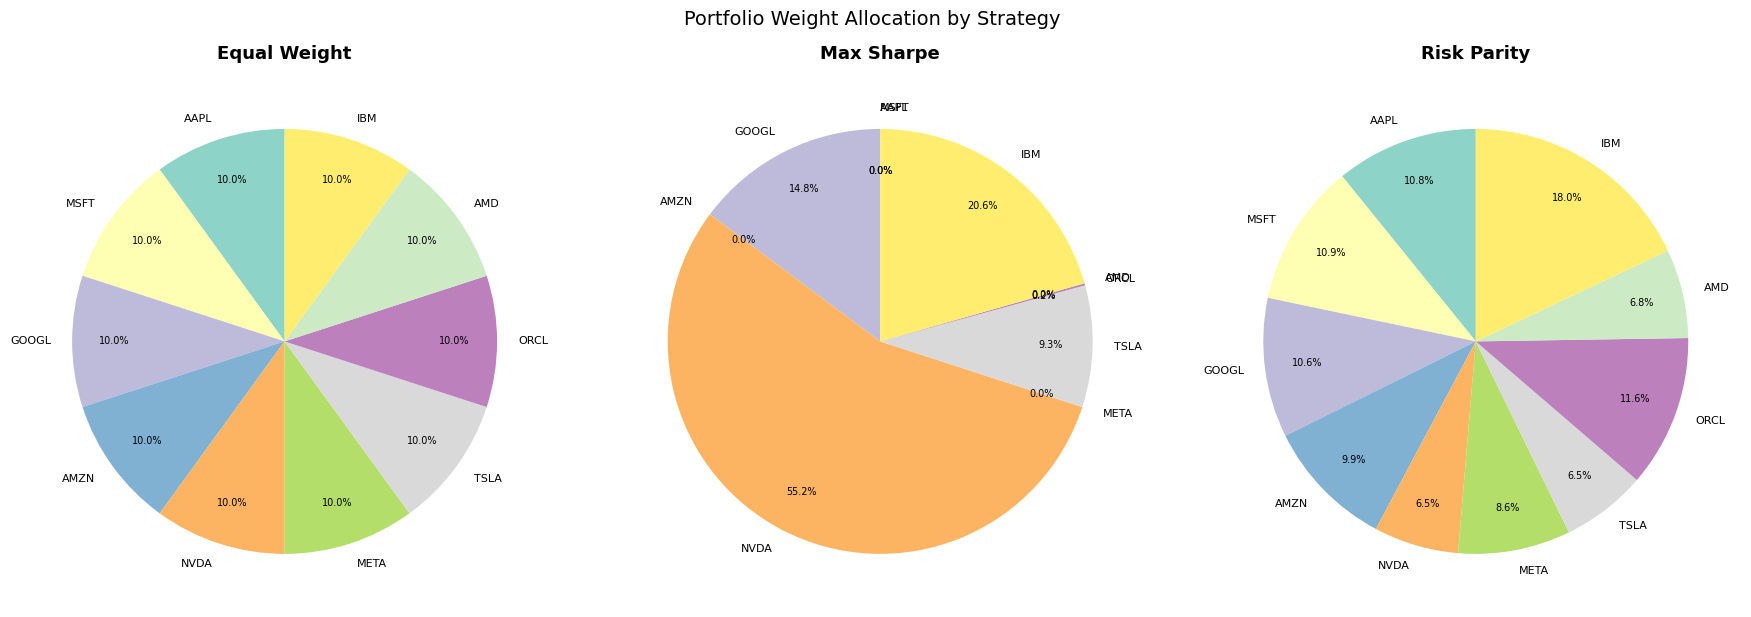

In [89]:
# Pie charts: Weight Allocation by strategy
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = plt.cm.Set3(np.linspace(0, 1, len(tickers)))

for ax, strat, w in zip(axes,
                         ['Equal Weight', 'Max Sharpe', 'Risk Parity'],
                         [eq_weights,     ms_weights,   rp_weights]):
    wedges, texts, autotexts = ax.pie(
        w, labels=tickers, autopct='%1.1f%%',
        colors=colors, startangle=90,
        pctdistance=0.8, textprops={'fontsize': 8}
    )
    for at in autotexts:
        at.set_fontsize(7)
    ax.set_title(strat, fontsize=13, fontweight='bold', pad=12)

plt.suptitle('Portfolio Weight Allocation by Strategy', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()